In [11]:
#install if needed

#%pip install rasterio

In [4]:
# This can either be:
# 1) a single dataset folder containing images/ and labels/ such as the Thomas dataset
# OR
# 2) a parent folder containing multiple dataset folders, such as the ThousandOaks dataset
#
# BASE_DIR = "/home/pid/Z1_Roads_Thomas"
# BASE_DIR = "/home/pid/Corona/Z6_CalFire_BlueRidge"

BASE_DIR = "C:\\Users\\dylan\\Downloads\\capstoneData\\Pala_Mesa_Roads_Rails"

In [5]:
import os
from collections import Counter
import numpy as np
import rasterio


def read_mask(path):
    with rasterio.open(path) as src:
        return src.read(1)

def is_dataset_folder(path):
    return os.path.isdir(path) and "images" in os.listdir(path) and "labels" in os.listdir(path)

def get_dataset_folders(base_dir):
    if is_dataset_folder(base_dir):
        return [base_dir]

    dataset_paths = []
    for name in sorted(os.listdir(base_dir)):
        full_path = os.path.join(base_dir, name)
        if is_dataset_folder(full_path):
            dataset_paths.append(full_path)

    return dataset_paths

dataset_paths = get_dataset_folders(BASE_DIR)

if not dataset_paths:
    raise ValueError("No dataset folders found.")

print("\n===== DATA INSPECTION SUMMARY =====\n")

for dataset_path in dataset_paths:
    dataset_name = os.path.basename(dataset_path)
    images_dir = os.path.join(dataset_path, "images")
    labels_dir = os.path.join(dataset_path, "labels")

    print(f"--- {dataset_name} ---")

    image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".tif")])
    label_files = sorted([f for f in os.listdir(labels_dir) if f.lower().endswith(".tif")])

    image_bases = {os.path.splitext(f)[0] for f in image_files}
    label_bases = {os.path.splitext(f)[0] for f in label_files}

    missing_labels = sorted(image_bases - label_bases)
    missing_images = sorted(label_bases - image_bases)
    matched_bases = sorted(image_bases & label_bases)

    print("Image files:", len(image_files))
    print("Label files:", len(label_files))
    print("Matched pairs:", len(matched_bases))
    print("Images with no label:", len(missing_labels))
    print("Labels with no image:", len(missing_images))

    if len(matched_bases) == 0:
        print("No matched pairs found.\n")
        continue

    pixel_counter = Counter()
    classes_present = set()
    shape_mismatches = 0
    images_with_label = Counter()
    dominant_label_counter = Counter()

    for base in matched_bases:
        img_path = os.path.join(images_dir, base + ".tif")
        lbl_path = os.path.join(labels_dir, base + ".tif")

        with rasterio.open(img_path) as src:
            img_shape = (src.height, src.width)

        lbl = read_mask(lbl_path)
        lbl_shape = lbl.shape

        if img_shape != lbl_shape:
            shape_mismatches += 1

        vals, counts = np.unique(lbl, return_counts=True)
        classes_present.update(vals.tolist())

        for v, c in zip(vals, counts):
            pixel_counter[int(v)] += int(c)

        for v in vals:
            images_with_label[int(v)] += 1

        dominant = int(vals[np.argmax(counts)])
        dominant_label_counter[dominant] += 1

    total_pixels = sum(pixel_counter.values())

    print("Classes present:", sorted(int(v) for v in classes_present))
    print("Number of classes present:", len(classes_present))
    print("Shape mismatches:", shape_mismatches)

    print("Label distribution (percent of total pixels):")
    for val in sorted(pixel_counter):
        pct = 100 * pixel_counter[val] / total_pixels
        print(f"  Label {val}: {pct:.2f}%")

    #Suggested weights using inverse frequency
    print("Suggested class weights (normalized inverse frequency, capped at 10):")
    
    num_classes = len(classes_present)
    max_weight = 10
    suggested_weights = {}
    
    for val in sorted(pixel_counter):
        weight = total_pixels / (num_classes * pixel_counter[val])
        weight = min(weight, max_weight)
        suggested_weights[val] = weight
        print(f"  Label {val}: {weight:.2f}")

    print("Images containing each label:")
    for val in sorted(images_with_label):
        print(f"  Label {val}: {images_with_label[val]}")

    print("Dominant label per image:")
    for val in sorted(dominant_label_counter):
        print(f"  Label {val}: {dominant_label_counter[val]}")

    print()

print("===== DONE =====")


===== DATA INSPECTION SUMMARY =====

--- Pala_Mesa_Roads_Rails ---
Image files: 1532
Label files: 1532
Matched pairs: 1532
Images with no label: 0
Labels with no image: 0
Classes present: [0, 1, 2, 3, 4]
Number of classes present: 5
Shape mismatches: 0
Label distribution (percent of total pixels):
  Label 0: 77.73%
  Label 1: 5.41%
  Label 2: 6.04%
  Label 3: 7.82%
  Label 4: 3.00%
Suggested class weights (normalized inverse frequency, capped at 10):
  Label 0: 0.26
  Label 1: 3.69
  Label 2: 3.31
  Label 3: 2.56
  Label 4: 6.67
Images containing each label:
  Label 0: 1532
  Label 1: 596
  Label 2: 631
  Label 3: 726
  Label 4: 365
Dominant label per image:
  Label 0: 1503
  Label 2: 2
  Label 3: 21
  Label 4: 6

===== DONE =====


Using dataset: Pala_Mesa_Roads_Rails
Matched image-label pairs: 1532


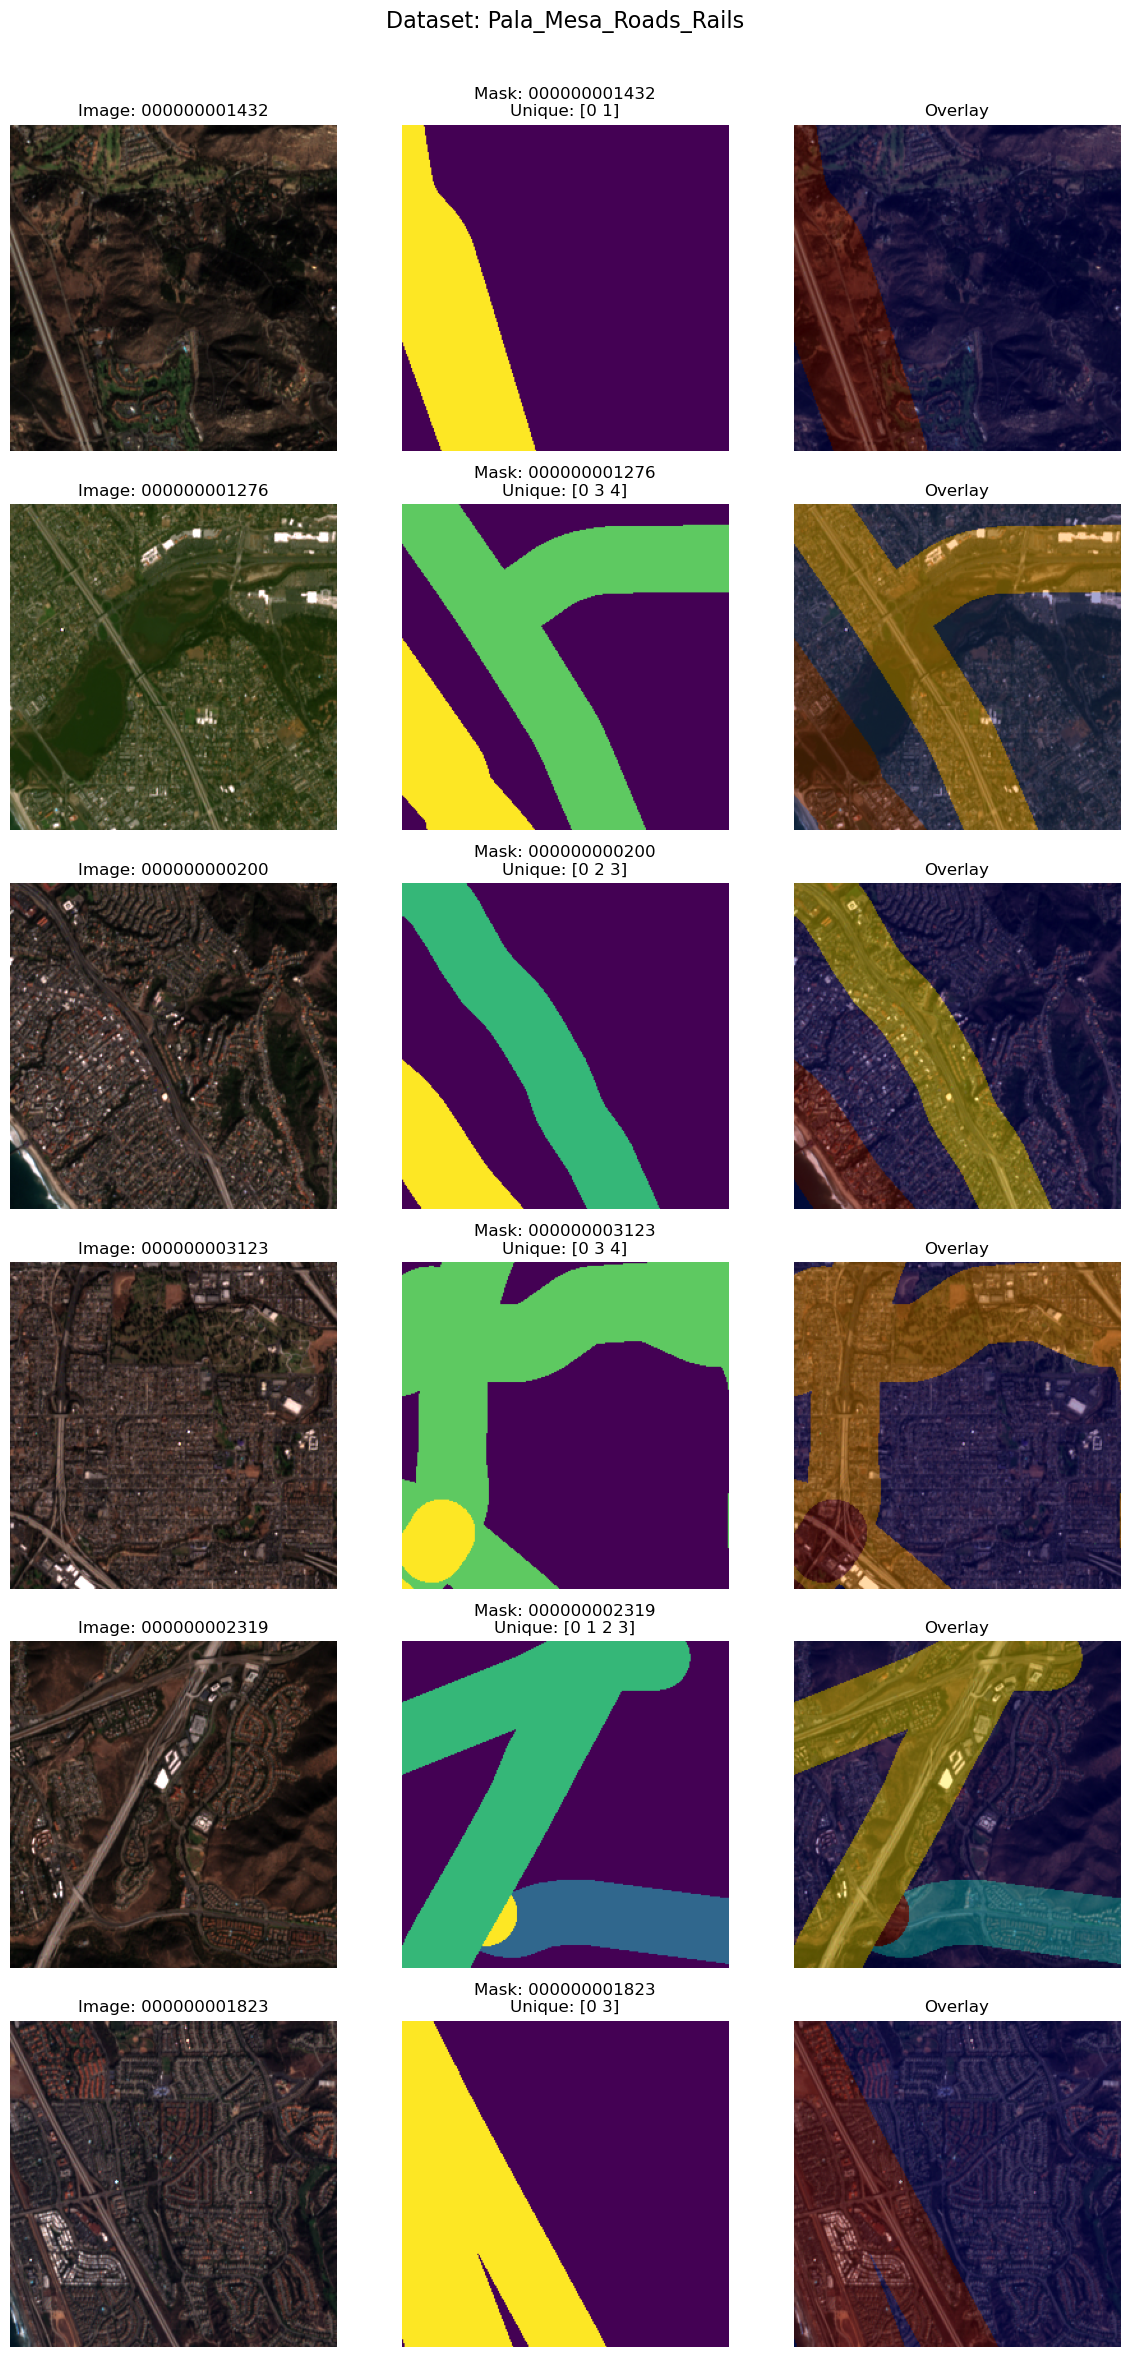

In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# BASE_DIR can be either:
# 1) a single dataset folder with images/ and labels/
# 2) a parent folder containing multiple dataset folders
# Example:
# BASE_DIR = r"C:\Users\dylan\Downloads\capstoneData\PalaMesa_Roads_Rails"
# BASE_DIR = r"C:\Users\dylan\Downloads\capstoneData\San Fernando\San Fernando"

def is_dataset_folder(path):
    return os.path.isdir(path) and "images" in os.listdir(path) and "labels" in os.listdir(path)

def get_dataset_folders(base_dir):
    # Case 1: BASE_DIR itself is a dataset folder
    if is_dataset_folder(base_dir):
        return [base_dir]

    # Case 2: BASE_DIR contains multiple dataset folders
    dataset_paths = [
        os.path.join(base_dir, d)
        for d in os.listdir(base_dir)
        if is_dataset_folder(os.path.join(base_dir, d))
    ]
    return dataset_paths

dataset_paths = get_dataset_folders(BASE_DIR)

if not dataset_paths:
    raise ValueError("No dataset folders found. Check BASE_DIR.")

# pick one dataset randomly
dataset_path = random.choice(dataset_paths)
dataset_name = os.path.basename(dataset_path)

# manually choose dataset instead if you want:
# DATASET_NAME = "Z3_Roads_Rails_Creek"
# dataset_path = os.path.join(BASE_DIR, DATASET_NAME)
# dataset_name = DATASET_NAME

# sanity check
if not os.path.exists(dataset_path):
    raise ValueError(f"Dataset not found: {dataset_path}")

print("Using dataset:", dataset_name)

# now set image/label paths for that dataset
IMAGES_DIR = os.path.join(dataset_path, "images")
LABELS_DIR = os.path.join(dataset_path, "labels")

# reads image, converts to H, W, C format
def read_image(path):
    with rasterio.open(path) as src:
        arr = src.read()  # (bands, height, width)
    arr = np.transpose(arr, (1, 2, 0))  # -> (height, width, bands)
    return arr

# reads label
def read_mask(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
    return arr

# normalizes image value for display
def normalize_for_display(img):
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for c in range(img.shape[2]):
        band = img[:, :, c]
        band_min = band.min()
        band_max = band.max()

        if band_max > band_min:
            out[:, :, c] = (band - band_min) / (band_max - band_min)

    return out

# get matched image-label pairs
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(".tif")])
label_files = sorted([f for f in os.listdir(LABELS_DIR) if f.lower().endswith(".tif")])

image_bases = {os.path.splitext(f)[0] for f in image_files}
label_bases = {os.path.splitext(f)[0] for f in label_files}
matched_bases = sorted(image_bases & label_bases)

if len(matched_bases) == 0:
    raise ValueError("No matching image-label pairs found.")

print("Matched image-label pairs:", len(matched_bases))

# Number of random samples to show
N_SAMPLES = 6
sample_bases = random.sample(matched_bases, min(N_SAMPLES, len(matched_bases)))

# creates the figure, row = one sample, column = image/mask/overlay
fig, axes = plt.subplots(len(sample_bases), 3, figsize=(12, 4 * len(sample_bases)))
fig.suptitle(f"Dataset: {dataset_name}", fontsize=16)

if len(sample_bases) == 1:
    axes = np.expand_dims(axes, axis=0)

# looping through sampled images
for row, base in enumerate(sample_bases):
    img_path = os.path.join(IMAGES_DIR, base + ".tif")
    lbl_path = os.path.join(LABELS_DIR, base + ".tif")

    img = read_image(img_path)
    lbl = read_mask(lbl_path)
    img_disp = normalize_for_display(img)

    # column 1: original image
    axes[row, 0].imshow(img_disp)
    axes[row, 0].set_title(f"Image: {base}")
    axes[row, 0].axis("off")

    # column 2: mask only
    axes[row, 1].imshow(lbl, cmap="viridis")
    axes[row, 1].set_title(f"Mask: {base}\nUnique: {np.unique(lbl)}")
    axes[row, 1].axis("off")

    # column 3: overlay
    axes[row, 2].imshow(img_disp)
    axes[row, 2].imshow(lbl, cmap="jet", alpha=0.35)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Unique values: [0 3 4]


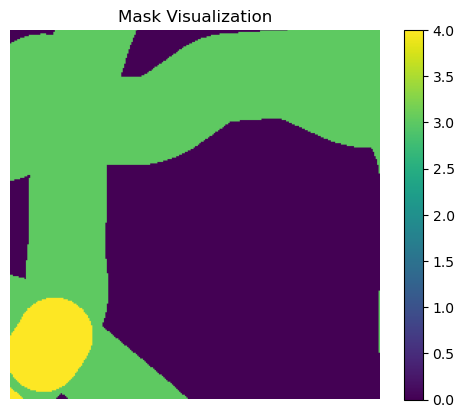

In [8]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

#mask_path = "/home/dfair/Corona/Z6_CalFire_BlueRidge/labels/import matplotlib.pyplot as plt
import rasterio
import numpy as np

mask_path = "C:\\Users\\dylan\\Downloads\\capstoneData\\Pala_Mesa_Roads_Rails\\labels\\000000003123.tif"
with rasterio.open(mask_path) as src:
    mask = src.read(1)

print("Unique values:", np.unique(mask))

plt.imshow(mask, cmap="viridis")
plt.colorbar()
plt.title("Mask Visualization")
plt.axis("off")
plt.show()